<a href="https://www.kaggle.com/code/lalit7881/ev-battery-qc-synthetic-data?scriptVersionId=301338265" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/ev-battery-qc-synthetic-defect-dataset/ev_battery_qc_data_2026_kaggle.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/ev-battery-qc-synthetic-defect-dataset/ev_battery_qc_data_2026_kaggle.csv")

In [3]:
df.head()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,NaN,Scrap
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,NaN,NaN,Grade A
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,NaN,Routine visual inspection passed.,Grade A
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,NaN,NaN,Grade A
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,NaN,Grade A


In [4]:
df.tail()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
19995,CELL-009308,BTH-0499,Line_1,Night,VoltIndustries,20.31,0.129,14.98,14.99,4997.0,96.58,NaN,NaN,Grade A
19996,CELL-011250,BTH-0499,Line_3,Evening,VoltIndustries,21.52,0.119,14.95,14.50,5031.0,97.17,NaN,NaN,Grade B
19997,CELL-003841,BTH-0499,Line_2,Morning,ChemCorp,24.40,0.106,15.05,13.82,4993.0,97.34,NaN,NaN,Scrap
19998,CELL-000715,BTH-0499,Line_1,Evening,VoltIndustries,23.87,0.151,15.06,15.28,4970.0,97.09,High Internal Resistance,NaN,Grade B
19999,CELL-005509,BTH-0499,Line_2,Morning,ChemCorp,24.07,0.112,14.98,14.61,5014.0,95.80,NaN,NaN,Scrap


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cell_ID                   20000 non-null  object 
 1   Batch_ID                  20000 non-null  object 
 2   Production_Line           20000 non-null  object 
 3   Shift                     20000 non-null  object 
 4   Supplier                  20000 non-null  object 
 5   Ambient_Temp_C            19400 non-null  float64
 6   Anode_Overhang_mm         20000 non-null  float64
 7   Electrolyte_Volume_ml     20000 non-null  float64
 8   Internal_Resistance_mOhm  20000 non-null  float64
 9   Capacity_mAh              20000 non-null  float64
 10  Retention_50Cycle_Pct     20000 non-null  float64
 11  Defect_Type               3501 non-null   object 
 12  Inspector_Comment         1667 non-null   object 
 13  QC_Grade                  20000 non-null  object 
dtypes: flo

In [6]:
df.describe()

,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct
count,19400.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.157409,0.137498,14.979050,14.280926,4988.398450,96.801533
std,1.890930,0.020991,0.119464,0.705987,48.205605,1.170866
min,16.260000,0.057000,14.430000,11.900000,4576.000000,90.210000
25%,21.860000,0.123000,14.910000,13.790000,4971.000000,96.350000
50%,23.250000,0.138000,14.990000,14.200000,4995.000000,96.940000
75%,24.490000,0.152000,15.060000,14.680000,5017.000000,97.510000
max,29.790000,0.219000,15.370000,17.640000,5120.000000,100.840000


In [7]:
df.dtypes

Cell_ID                      object
Batch_ID                     object
Production_Line              object
Shift                        object
Supplier                     object
Ambient_Temp_C              float64
Anode_Overhang_mm           float64
Electrolyte_Volume_ml       float64
Internal_Resistance_mOhm    float64
Capacity_mAh                float64
Retention_50Cycle_Pct       float64
Defect_Type                  object
Inspector_Comment            object
QC_Grade                     object
dtype: object

In [8]:
df.shape

(20000, 14)

In [9]:
df.isnull().sum()

Cell_ID                         0
Batch_ID                        0
Production_Line                 0
Shift                           0
Supplier                        0
Ambient_Temp_C                600
Anode_Overhang_mm               0
Electrolyte_Volume_ml           0
Internal_Resistance_mOhm        0
Capacity_mAh                    0
Retention_50Cycle_Pct           0
Defect_Type                 16499
Inspector_Comment           18333
QC_Grade                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

Cell_ID                     20000
Batch_ID                      499
Production_Line                 3
Shift                           3
Supplier                        3
Ambient_Temp_C               1058
Anode_Overhang_mm             148
Electrolyte_Volume_ml          92
Internal_Resistance_mOhm      468
Capacity_mAh                  402
Retention_50Cycle_Pct         824
Defect_Type                     6
Inspector_Comment               7
QC_Grade                        3
dtype: int64

In [12]:
df.columns

Index(['Cell_ID', 'Batch_ID', 'Production_Line', 'Shift', 'Supplier',
       'Ambient_Temp_C', 'Anode_Overhang_mm', 'Electrolyte_Volume_ml',
       'Internal_Resistance_mOhm', 'Capacity_mAh', 'Retention_50Cycle_Pct',
       'Defect_Type', 'Inspector_Comment', 'QC_Grade'],
      dtype='object')

## EDA

In [13]:
sns.set_style("whitegrid")

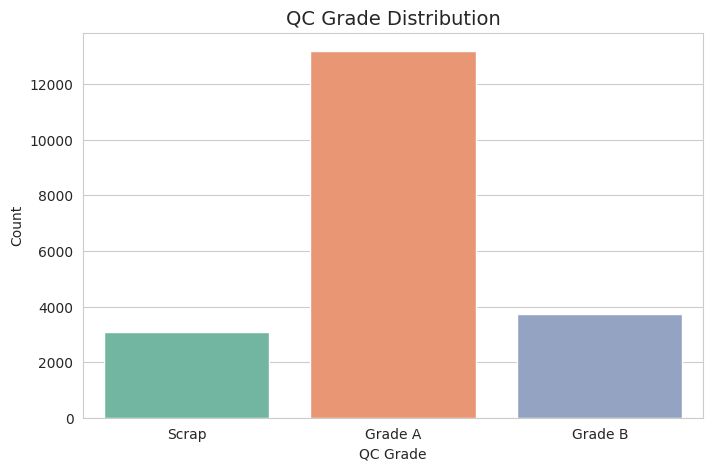

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='QC_Grade', data=df, palette='Set2')
plt.title("QC Grade Distribution", fontsize=14)
plt.xlabel("QC Grade")
plt.ylabel("Count")
plt.show()

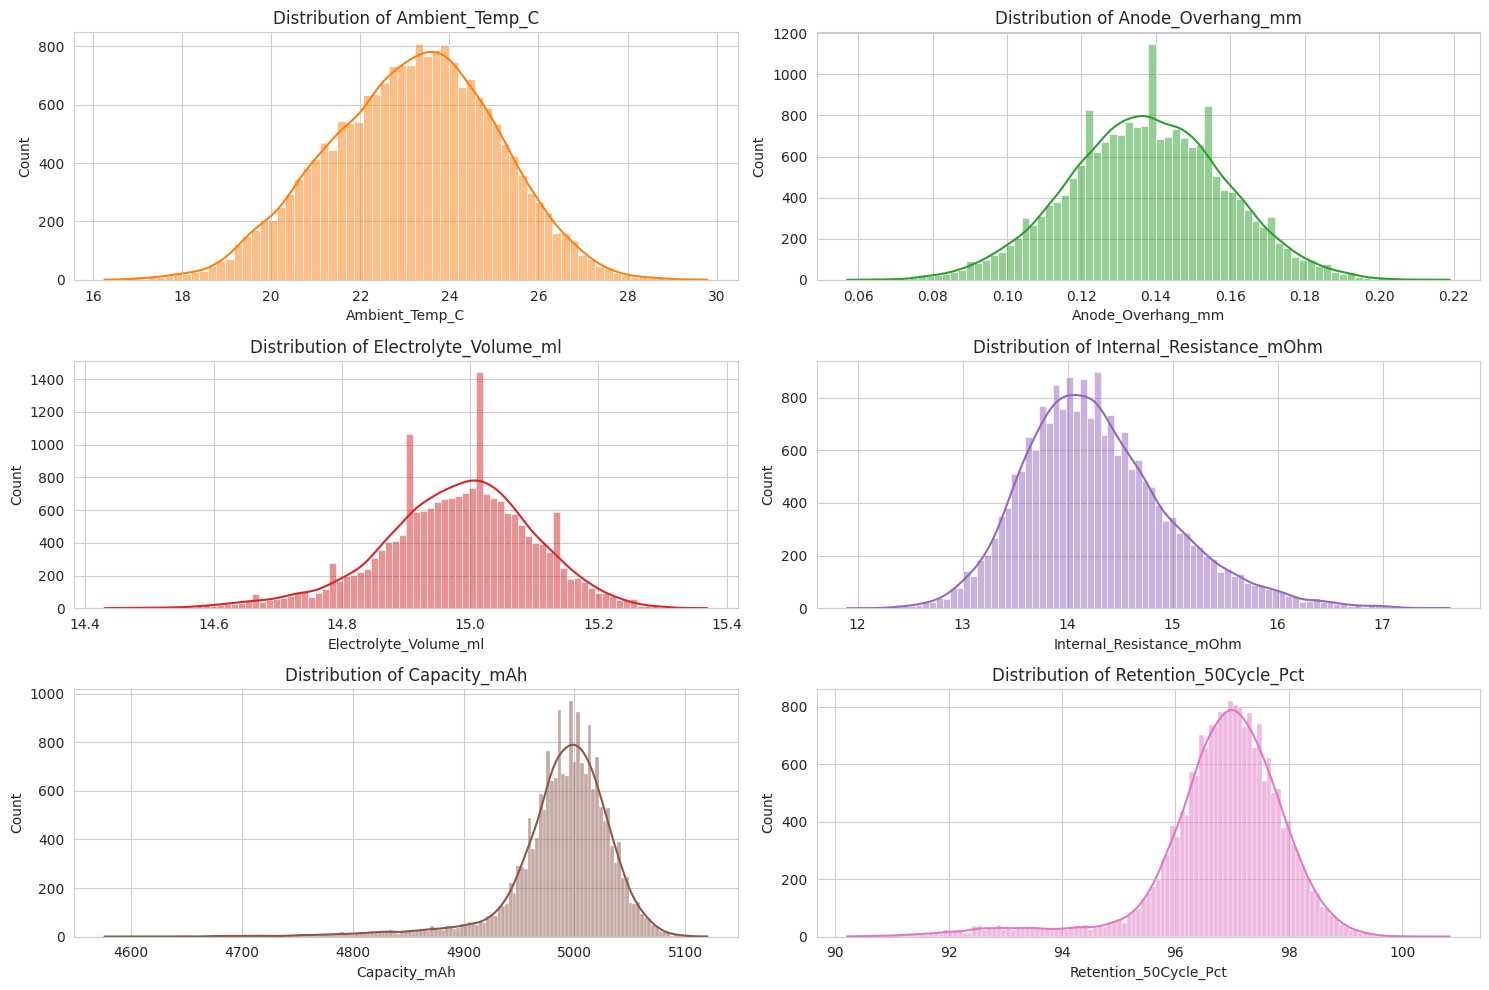

In [15]:
num_cols = [
    'Ambient_Temp_C',
    'Anode_Overhang_mm',
    'Electrolyte_Volume_ml',
    'Internal_Resistance_mOhm',
    'Capacity_mAh',
    'Retention_50Cycle_Pct'
]

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)
    sns.histplot(df[col], kde=True, color=sns.color_palette("tab10")[i])
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

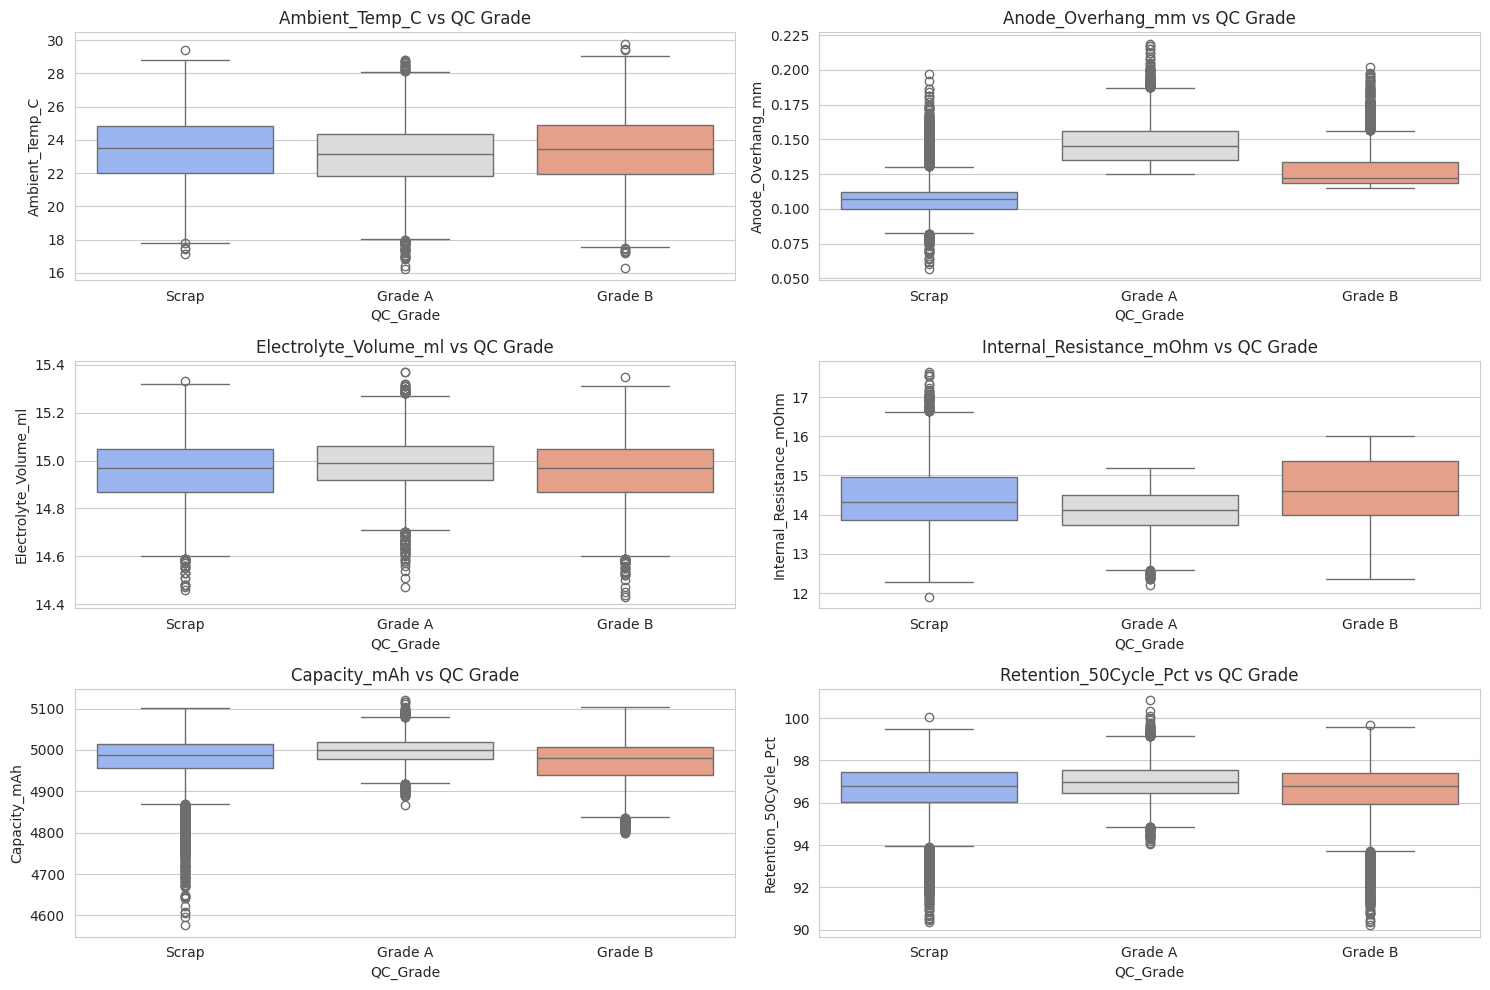

In [16]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)
    sns.boxplot(x='QC_Grade', y=col, data=df, palette='coolwarm')
    plt.title(f"{col} vs QC Grade")

plt.tight_layout()
plt.show()

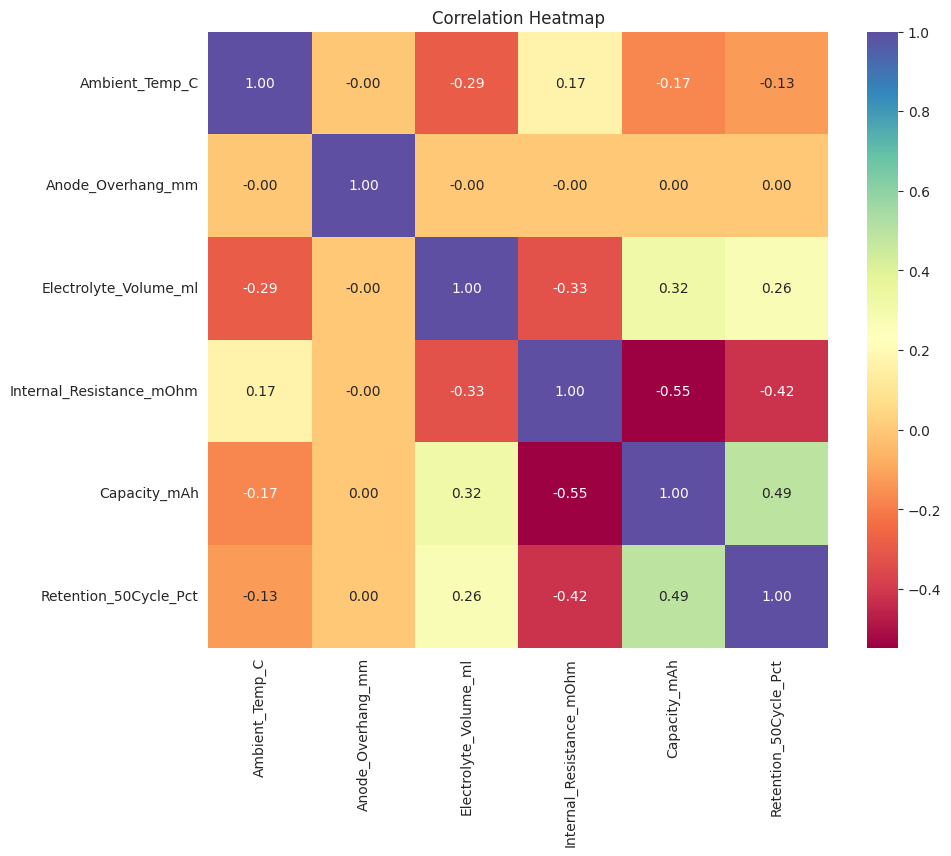

In [17]:
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='Spectral', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

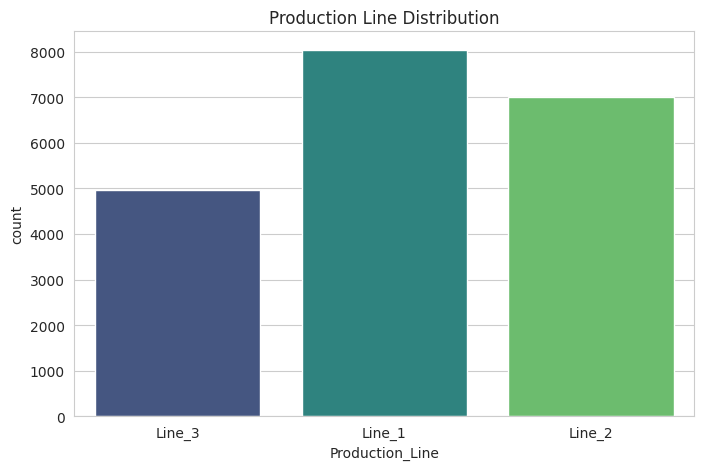

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Production_Line', data=df, palette='viridis')
plt.title("Production Line Distribution")
plt.show()

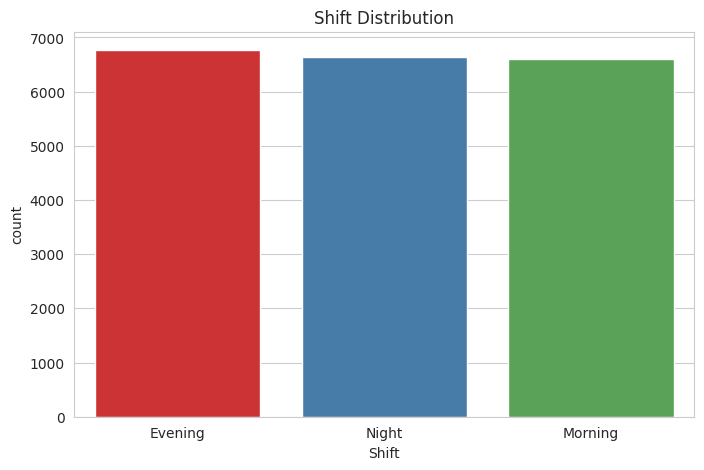

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Shift', data=df, palette='Set1')
plt.title("Shift Distribution")
plt.show()

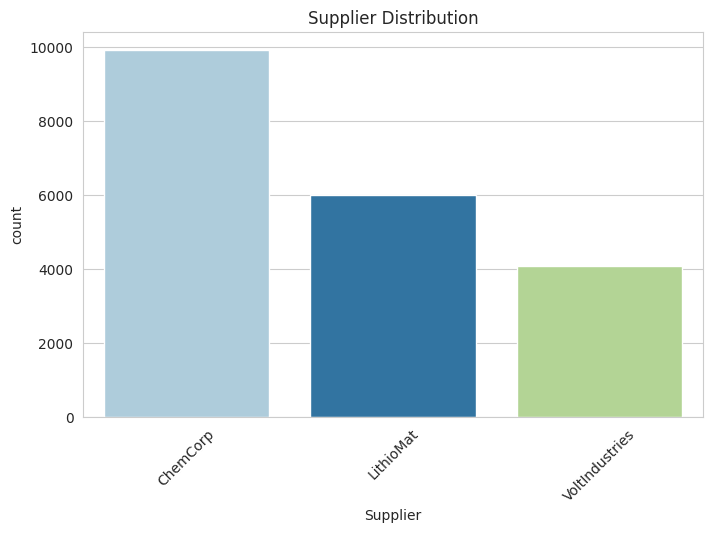

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='Supplier', data=df, palette='Paired')
plt.title("Supplier Distribution")
plt.xticks(rotation=45)
plt.show()

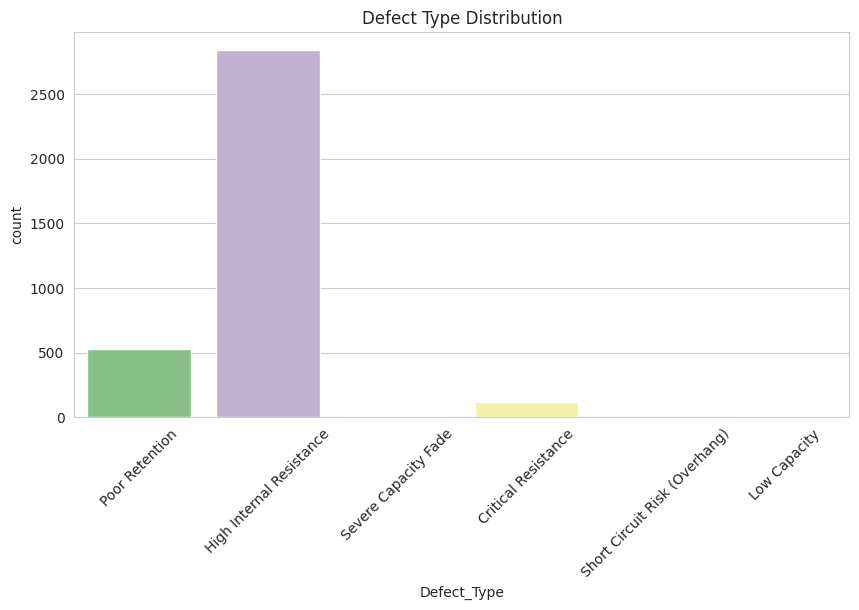

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(x='Defect_Type', data=df, palette='Accent')
plt.title("Defect Type Distribution")
plt.xticks(rotation=45)
plt.show()

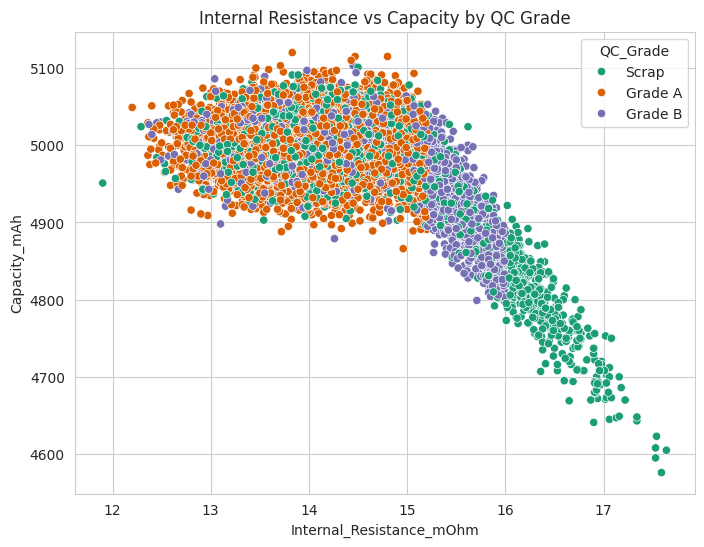

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Internal_Resistance_mOhm',
    y='Capacity_mAh',
    hue='QC_Grade',
    palette='Dark2',
    data=df
)
plt.title("Internal Resistance vs Capacity by QC Grade")
plt.show()

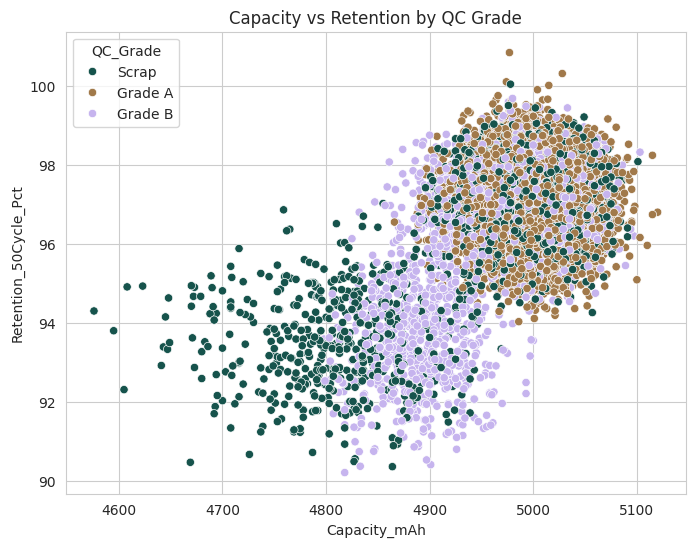

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Capacity_mAh',
    y='Retention_50Cycle_Pct',
    hue='QC_Grade',
    palette='cubehelix',
    data=df
)
plt.title("Capacity vs Retention by QC Grade")
plt.show()

## Feature engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [25]:
df = df.drop(columns=["Inspector_Comment", "Cell_ID", "Batch_ID"], errors="ignore")

# Fill missing values
df["Ambient_Temp_C"] = df["Ambient_Temp_C"].fillna(df["Ambient_Temp_C"].median())
df["Defect_Type"] = df["Defect_Type"].fillna("No_Defect")


In [26]:
X = df.drop("QC_Grade", axis=1)
y = df["QC_Grade"]

In [27]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [29]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

In [31]:
for name, model in models.items():
    
    pipe = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy: {:.2f}%".format(acc))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 88.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2639
           1       0.72      0.64      0.68       747
           2       0.90      0.85      0.88       614

    accuracy                           0.89      4000
   macro avg       0.85      0.82      0.83      4000
weighted avg       0.88      0.89      0.88      4000


Random Forest
Accuracy: 99.98%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2639
           1       1.00      1.00      1.00       747
           2       1.00      1.00      1.00       614

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


SVM
Accuracy: 97.45%

Classification Report:
              precision    recall  f1-score   support

           0       

In [32]:
if len(np.unique(y)) == 2:
    
    plt.figure(figsize=(8,6))
    
    for name, model in models.items():
        pipe = Pipeline(steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ])
        
        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:,1]
        
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

## Thank you..pls upvote!!!!